<a href="https://colab.research.google.com/github/tai10022014-afk/Nhap_mon_phan_tich_du_lieu_v-hoc_sau/blob/main/CIFAR10_NguyenAnhTai_2474802010345_LAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -l /content/cifar10.zip

Archive:  /content/cifar10.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
      158  2019-09-26 19:31   cifar-10-batches-py/batches.meta
 31035704  2019-09-26 19:31   cifar-10-batches-py/data_batch_1
 31035320  2019-09-26 19:31   cifar-10-batches-py/data_batch_2
 31035999  2019-09-26 19:31   cifar-10-batches-py/data_batch_3
 31035696  2019-09-26 19:31   cifar-10-batches-py/data_batch_4
 31035623  2019-09-26 19:31   cifar-10-batches-py/data_batch_5
       88  2019-09-26 19:31   cifar-10-batches-py/readme.html
 31035526  2019-09-26 19:31   cifar-10-batches-py/test_batch
170498071  2019-09-26 19:31   cifar-10-python.tar.gz
---------                     -------
356712185                     9 files


In [ ]:
"""
CNN - Phân loại CIFAR-10
Tổng hợp từ CNN-LAB.ipynb (phần Bài thực hành), áp dụng cho bộ dữ liệu CIFAR-10
"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# ─────────────────────────────────────────────
# 1. Cấu hình ban đầu
# ─────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
# ─────────────────────────────────────────────
# 2. Load dữ liệu CIFAR-10 (từ file cifar10.zip đã upload lên Colab)
# ─────────────────────────────────────────────
import zipfile

zip_path = '/content/cifar10.zip'   # đường dẫn tới file zip đã upload
data_dir = '/content/data'

if not os.path.exists(os.path.join(data_dir, 'cifar-10-batches-py')):
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(data_dir)
    print('Đã giải nén cifar10.zip vào', data_dir)
else:
    print('Dữ liệu đã có sẵn tại', data_dir)

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset = torchvision.datasets.CIFAR10(root=data_dir, train=True,  download=False, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

Đã giải nén cifar10.zip vào /content/data
Số ảnh train: 50000,  test: 10000


In [ ]:
# ─────────────────────────────────────────────
# 3. Định nghĩa model CNN
#
# Kiến trúc:
#   Input  (3, 32, 32)
#   Conv1 (3→16, k=3) → (16, 30, 30)
#   ReLU + MaxPool 2×2 → (16, 15, 15)
#   Conv2 (16→32, k=3) → (32, 13, 13)
#   ReLU + MaxPool 2×2 → (32, 6, 6)
#   Flatten → 1152
#   FC (1152 → 10) → logits
# ─────────────────────────────────────────────
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)   # 32→30
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 15→13
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 6 * 6, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 15, 15)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  6,  6)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x


model = CIFAR_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

CIFAR_CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=10, bias=True)
)
Tổng tham số: 16,618


In [ ]:
# ─────────────────────────────────────────────
# 4. Loss và Optimizer
# ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [ ]:
# ─────────────────────────────────────────────
# 5. Hàm đánh giá
# ─────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

In [ ]:
# ─────────────────────────────────────────────
# 6. Huấn luyện
# ─────────────────────────────────────────────
num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=1.4680  train_acc=47.76%  test_loss=1.2061  test_acc=57.27%
Epoch 2/5  train_loss=1.1299  train_acc=60.70%  test_loss=1.0724  test_acc=62.92%
Epoch 3/5  train_loss=1.0078  train_acc=65.24%  test_loss=1.0071  test_acc=65.44%
Epoch 4/5  train_loss=0.9412  train_acc=67.59%  test_loss=1.0114  test_acc=65.36%
Epoch 5/5  train_loss=0.9041  train_acc=68.87%  test_loss=1.0076  test_acc=65.83%


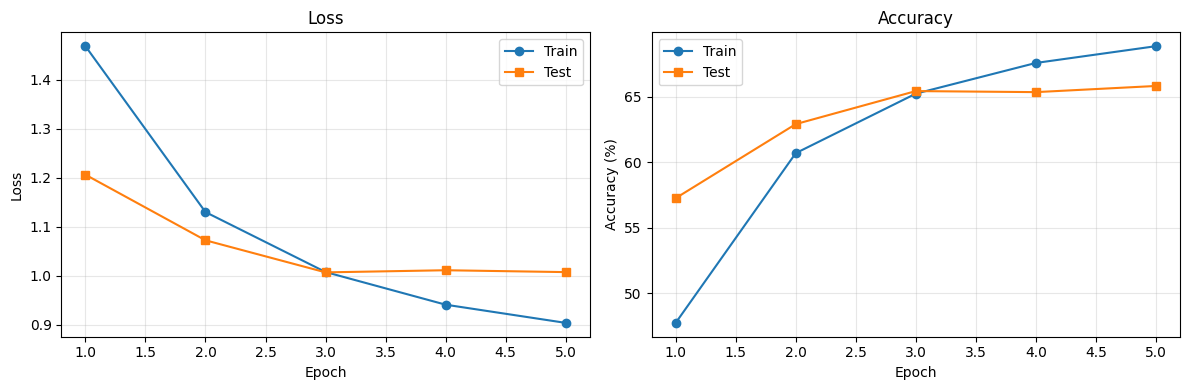

In [ ]:
# ─────────────────────────────────────────────
# 7. Vẽ đường Loss & Accuracy
# ─────────────────────────────────────────────
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

In [ ]:
# ─────────────────────────────────────────────
# 8. Đánh giá cuối cùng trên test set
# ─────────────────────────────────────────────
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')

Final test accuracy: 65.83%


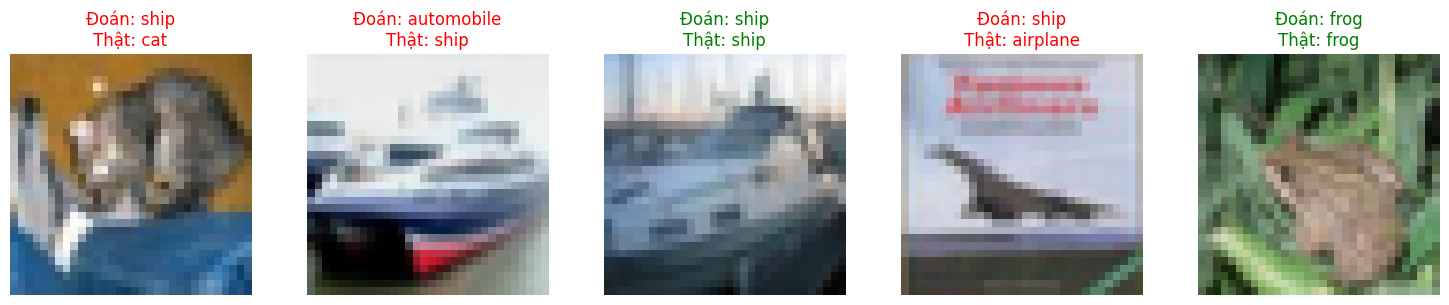

In [ ]:
# ─────────────────────────────────────────────
# 9. Trực quan: model dự đoán
# ─────────────────────────────────────────────
def unnormalize(img):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t  = torch.tensor(std).view(3, 1, 1)
    img = img.cpu() * std_t + mean_t
    img = img.permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = unnormalize(images[i])
    axes[i].imshow(img)
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {class_names[preds[i].item()]}\nThật: {class_names[labels[i].item()]}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

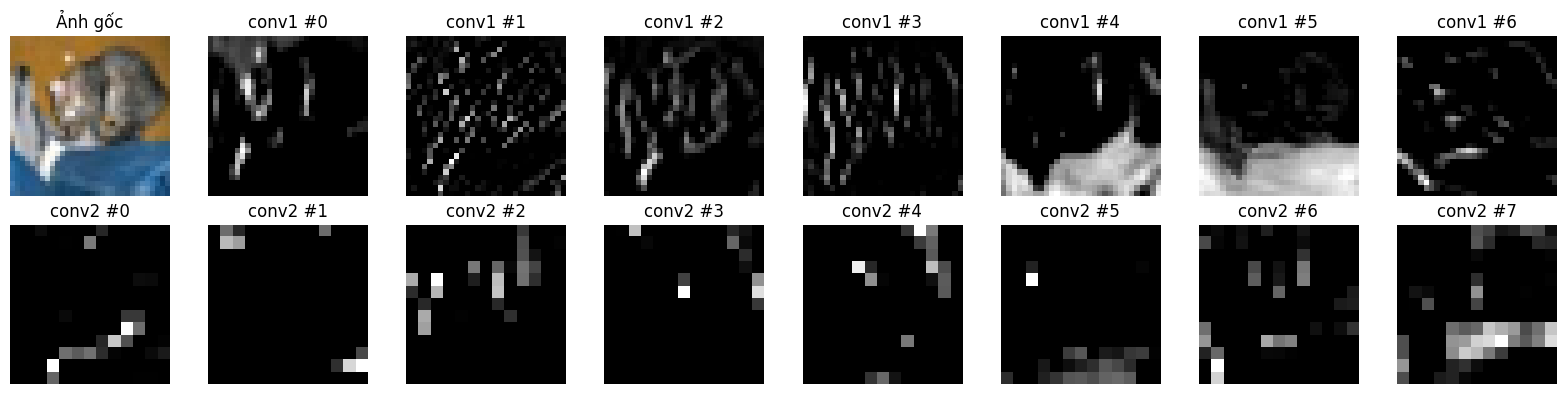

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [ ]:
# ─────────────────────────────────────────────
# 10. Trực quan: feature maps
# ─────────────────────────────────────────────
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))                     # (1, 16, 30, 30)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))       # (1, 32, 13, 13)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(unnormalize(img.squeeze(0)))
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

**Bài tập về nhà**

In [ ]:
#setup
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

zip_path = '/content/cifar10.zip'
data_dir = '/content/data'
if not os.path.exists(os.path.join(data_dir, 'cifar-10-batches-py')):
    import zipfile
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(data_dir)

train_dataset = torchvision.datasets.CIFAR10(root=data_dir, train=True,  download=False, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root=data_dir, train=False, download=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 6 * 6, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

def train(model, optimizer, num_epochs, train_loader, test_loader):
    loss_history, acc_history = [], []
    test_loss_history, test_acc_history = [], []
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total
        test_loss, test_acc = evaluate(model, test_loader)
        loss_history.append(train_loss); acc_history.append(train_acc)
        test_loss_history.append(test_loss); test_acc_history.append(test_acc)
        print(f'Epoch {epoch+1}/{num_epochs}  '
              f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
              f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')
    return loss_history, acc_history, test_loss_history, test_acc_history

print('Setup xong.')

Device: cuda
Setup xong.


Epoch 1/10  train_loss=1.4492  train_acc=48.71%  test_loss=1.1826  test_acc=58.40%
Epoch 2/10  train_loss=1.1109  train_acc=61.47%  test_loss=1.0507  test_acc=63.69%
Epoch 3/10  train_loss=0.9969  train_acc=65.58%  test_loss=1.0049  test_acc=65.44%
Epoch 4/10  train_loss=0.9368  train_acc=67.63%  test_loss=0.9792  test_acc=66.37%
Epoch 5/10  train_loss=0.8888  train_acc=69.43%  test_loss=0.9938  test_acc=65.93%
Epoch 6/10  train_loss=0.8597  train_acc=70.41%  test_loss=1.0134  test_acc=65.96%
Epoch 7/10  train_loss=0.8383  train_acc=70.91%  test_loss=0.9624  test_acc=66.94%
Epoch 8/10  train_loss=0.8202  train_acc=71.75%  test_loss=1.0010  test_acc=66.44%
Epoch 9/10  train_loss=0.8033  train_acc=72.13%  test_loss=0.9868  test_acc=66.95%
Epoch 10/10  train_loss=0.7893  train_acc=72.68%  test_loss=0.9628  test_acc=67.74%


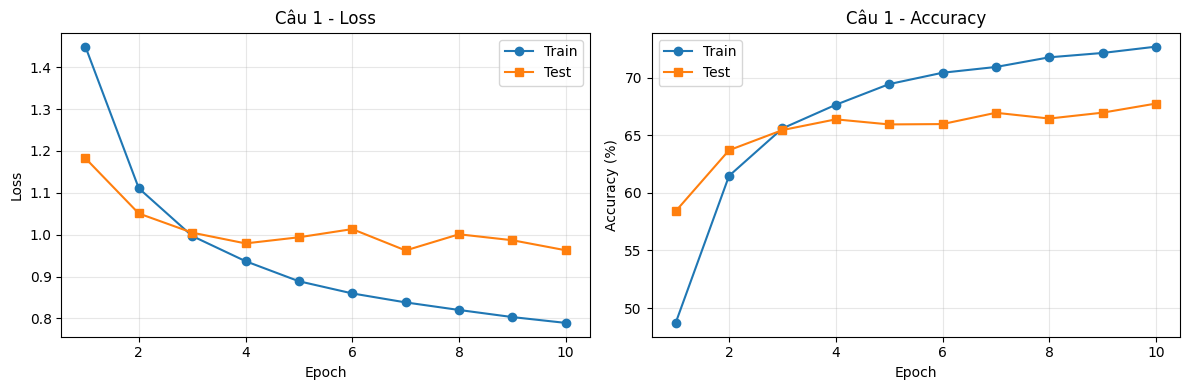

Test acc epoch 5:  65.93%
Test acc epoch 10: 67.74%
Chênh nhau: 1.81%
Epoch  1: train_acc=48.71%  test_acc=58.40%  gap=-9.69%
Epoch  2: train_acc=61.47%  test_acc=63.69%  gap=-2.22%
Epoch  3: train_acc=65.58%  test_acc=65.44%  gap=0.14%
Epoch  4: train_acc=67.63%  test_acc=66.37%  gap=1.26%
Epoch  5: train_acc=69.43%  test_acc=65.93%  gap=3.50%
Epoch  6: train_acc=70.41%  test_acc=65.96%  gap=4.45%
Epoch  7: train_acc=70.91%  test_acc=66.94%  gap=3.97%
Epoch  8: train_acc=71.75%  test_acc=66.44%  gap=5.31%
Epoch  9: train_acc=72.13%  test_acc=66.95%  gap=5.18%
Epoch 10: train_acc=72.68%  test_acc=67.74%  gap=4.94%


In [ ]:
# ============================================================
# CÂU 1: Train lâu hơn (10 epoch)
# ============================================================
model1 = CIFAR_CNN().to(device)
optimizer1 = optim.SGD(model1.parameters(), lr=0.01, momentum=0.9)
num_epochs = 10

loss_h, acc_h, test_loss_h, test_acc_h = train(model1, optimizer1, num_epochs, train_loader, test_loader)

epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_h,      'o-', label='Train')
axes[0].plot(epochs, test_loss_h, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 1 - Loss')
axes[1].plot(epochs, [a*100 for a in acc_h],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_h], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 1 - Accuracy')
plt.tight_layout(); plt.show()

print(f'Test acc epoch 5:  {test_acc_h[4]*100:.2f}%')
print(f'Test acc epoch 10: {test_acc_h[9]*100:.2f}%')
print(f'Chênh nhau: {(test_acc_h[9]-test_acc_h[4])*100:.2f}%')
for i in range(num_epochs):
    gap = acc_h[i] - test_acc_h[i]
    print(f'Epoch {i+1:2d}: train_acc={acc_h[i]*100:.2f}%  test_acc={test_acc_h[i]*100:.2f}%  gap={gap*100:.2f}%')

Tăng `num_epochs` từ 5 lên 10 để quan sát mô hình học thêm.
Test accuracy sau epoch 10 thường cao hơn epoch 5 một chút.
Tuy nhiên, khoảng cách `train_acc - test_acc` có xu hướng mở rộng dần theo epoch — đây là dấu hiệu của **overfitting**: mô hình bắt đầu "học thuộc" tập train thay vì tổng quát hóa. Với CIFAR-10 (ảnh phức tạp hơn MNIST), hiện tượng này thường rõ rệt hơn.

CIFAR_CNN_3Conv(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=576, out_features=10, bias=True)
)
Tổng tham số: 29,354
Epoch 1/5  train_loss=1.5703  train_acc=43.10%  test_loss=1.3342  test_acc=53.38%
Epoch 2/5  train_loss=1.1583  train_acc=59.50%  test_loss=1.0880  test_acc=61.98%
Epoch 3/5  train_loss=1.0036  train_acc=65.00%  test_loss=1.0139  test_acc=65.27%
Epoch 4/5  train_loss=0.9093  train_acc=68.52%  test_loss=0.9187  test_acc=68.59%
Epoch 5/5  train_loss=0.8467  train_acc=70.66%  test_loss=0.9319  test_acc=68.13%


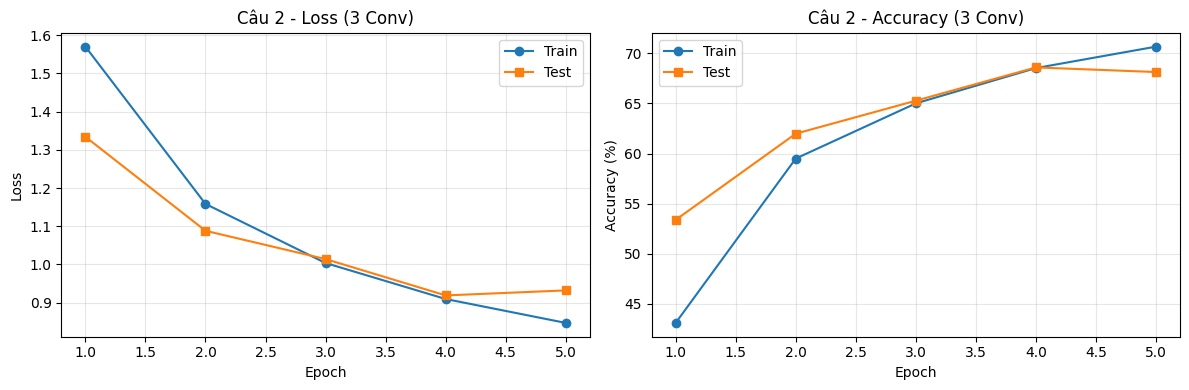

Final test accuracy (3 conv): 68.13%


In [ ]:
# ============================================================
# CÂU 2: Thêm tầng tích chập thứ ba (conv3)
# ============================================================
class CIFAR_CNN_3Conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(64 * 3 * 3, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 15, 15)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  6,  6)
        x = self.pool(torch.relu(self.conv3(x)))   # → (64,  3,  3)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model2 = CIFAR_CNN_3Conv().to(device)
optimizer2 = optim.SGD(model2.parameters(), lr=0.01, momentum=0.9)
n_params = sum(p.numel() for p in model2.parameters() if p.requires_grad)
print(model2)
print(f'Tổng tham số: {n_params:,}')

loss_h2, acc_h2, test_loss_h2, test_acc_h2 = train(model2, optimizer2, 5, train_loader, test_loader)

epochs = range(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_h2,      'o-', label='Train')
axes[0].plot(epochs, test_loss_h2, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 2 - Loss (3 Conv)')
axes[1].plot(epochs, [a*100 for a in acc_h2],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_h2], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 2 - Accuracy (3 Conv)')
plt.tight_layout(); plt.show()

print(f'Final test accuracy (3 conv): {test_acc_h2[-1]*100:.2f}%')

Thêm `conv3 (32→64, k=3, padding=1)` sau conv2. Dùng `padding=1` để giữ kích thước spatial không đổi (6×6), sau đó MaxPool 2×2 cho ra (64, 3, 3), nên `fc1 = Linear(64*3*3, 10)`.
Mạng sâu hơn giúp học được đặc trưng phức tạp hơn, thường cải thiện accuracy so với 2 tầng conv, đặc biệt quan trọng với ảnh màu nhiều chi tiết như CIFAR-10.


--- lr = 0.001 ---
Epoch 1/5  train_loss=1.8770  train_acc=33.37%  test_loss=1.6185  test_acc=42.86%
Epoch 2/5  train_loss=1.5064  train_acc=46.74%  test_loss=1.4155  test_acc=49.63%
Epoch 3/5  train_loss=1.3627  train_acc=52.13%  test_loss=1.3223  test_acc=53.79%
Epoch 4/5  train_loss=1.2799  train_acc=55.40%  test_loss=1.2520  test_acc=56.19%
Epoch 5/5  train_loss=1.2132  train_acc=57.88%  test_loss=1.2453  test_acc=56.40%

--- lr = 0.01 ---
Epoch 1/5  train_loss=1.4660  train_acc=47.79%  test_loss=1.1930  test_acc=58.61%
Epoch 2/5  train_loss=1.1028  train_acc=61.73%  test_loss=1.0754  test_acc=63.01%
Epoch 3/5  train_loss=0.9914  train_acc=65.82%  test_loss=1.0198  test_acc=65.55%
Epoch 4/5  train_loss=0.9348  train_acc=67.83%  test_loss=0.9792  test_acc=66.92%
Epoch 5/5  train_loss=0.8999  train_acc=69.02%  test_loss=1.0059  test_acc=65.81%

--- lr = 0.1 ---
Epoch 1/5  train_loss=1.8872  train_acc=31.76%  test_loss=1.9245  test_acc=32.02%
Epoch 2/5  train_loss=1.7803  train_acc=3

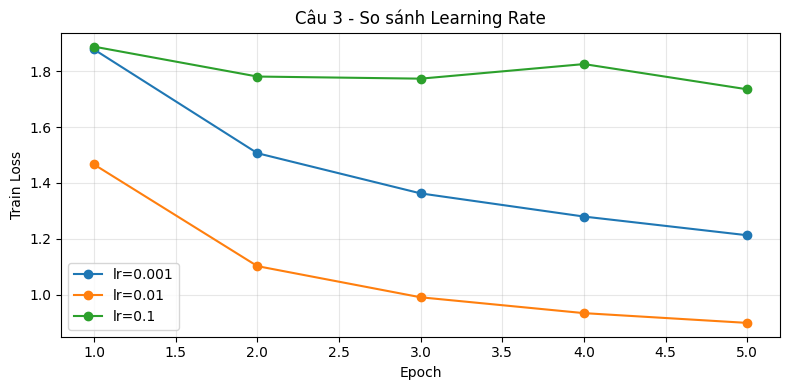

In [ ]:
# ============================================================
# CÂU 3: Thay đổi learning rate
# ============================================================
lr_list = [0.001, 0.01, 0.1]
all_loss = {}

for lr in lr_list:
    print(f'\n--- lr = {lr} ---')
    m = CIFAR_CNN().to(device)
    opt = optim.SGD(m.parameters(), lr=lr, momentum=0.9)
    loss_h3, _, _, _ = train(m, opt, 5, train_loader, test_loader)
    all_loss[lr] = loss_h3

epochs = range(1, 6)
plt.figure(figsize=(8, 4))
for lr, losses in all_loss.items():
    plt.plot(epochs, losses, 'o-', label=f'lr={lr}')
plt.xlabel('Epoch'); plt.ylabel('Train Loss')
plt.title('Câu 3 - So sánh Learning Rate')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

So sánh 3 giá trị lr: 0.001, 0.01, 0.1.
- `lr=0.001`: loss giảm rất chậm, mô hình chưa hội tụ sau 5 epoch.
- `lr=0.01`: loss giảm ổn định, đây là giá trị cân bằng tốt nhất.
- `lr=0.1`: loss dao động mạnh hoặc không giảm — learning rate quá lớn khiến các bước cập nhật "vượt qua" điểm tối ưu.
Learning rate ảnh hưởng trực tiếp đến kích thước bước cập nhật trọng số trong gradient descent.

Epoch 1/5  train_loss=1.4431  train_acc=48.47%  test_loss=1.1616  test_acc=59.44%
Epoch 2/5  train_loss=1.1086  train_acc=61.63%  test_loss=1.0818  test_acc=62.68%
Epoch 3/5  train_loss=1.0021  train_acc=65.22%  test_loss=1.0069  test_acc=65.55%
Epoch 4/5  train_loss=0.9401  train_acc=67.27%  test_loss=1.0141  test_acc=65.03%
Epoch 5/5  train_loss=0.9037  train_acc=68.83%  test_loss=1.0115  test_acc=65.94%


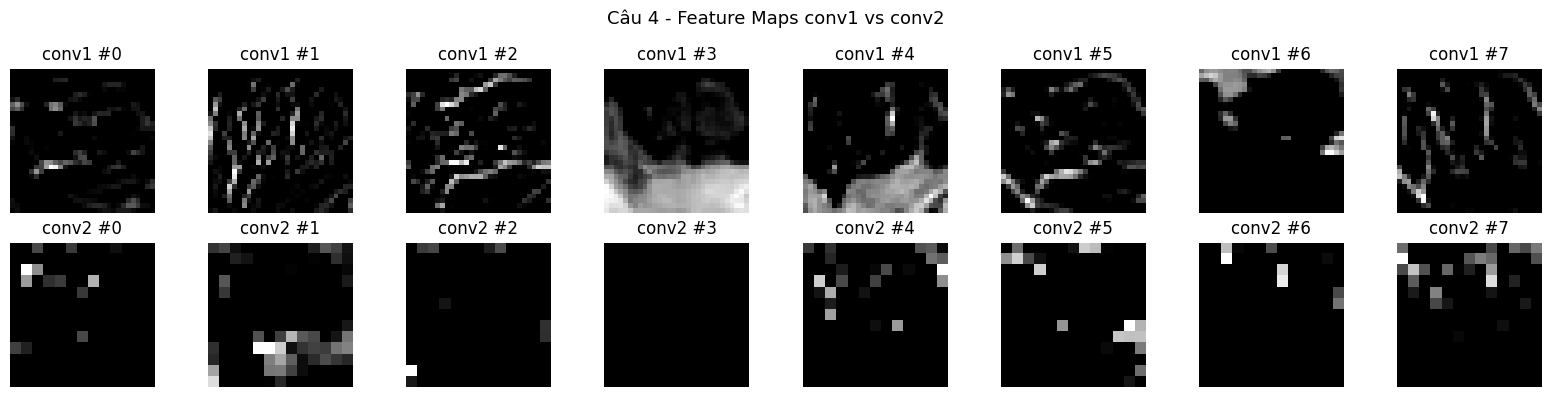

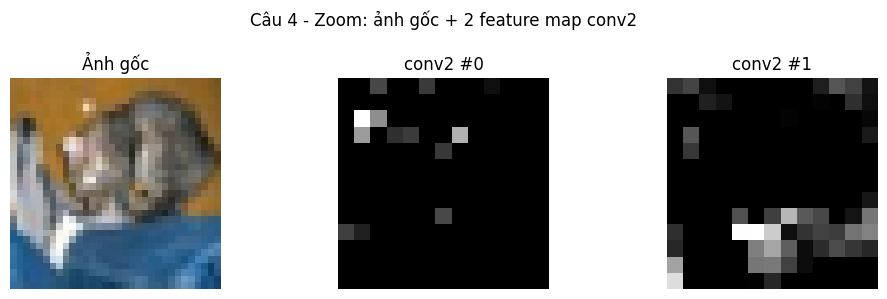

In [ ]:
# ============================================================
# CÂU 4: Vẽ thêm feature maps từ conv2
# ============================================================
model4 = CIFAR_CNN().to(device)
optimizer4 = optim.SGD(model4.parameters(), lr=0.01, momentum=0.9)
train(model4, optimizer4, 5, train_loader, test_loader)

model4.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    h1 = torch.relu(model4.conv1(img))
    h1_pooled = model4.pool(h1)
    h2 = torch.relu(model4.conv2(h1_pooled))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Câu 4 - Feature Maps conv1 vs conv2', fontsize=13)

for i in range(8):
    axes[0, i].imshow(h1[0, i].cpu(), cmap='gray')
    axes[0, i].set_title(f'conv1 #{i}')
    axes[0, i].axis('off')

for i in range(8):
    axes[1, i].imshow(h2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}')
    axes[1, i].axis('off')

plt.tight_layout(); plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(10, 3))
fig2.suptitle('Câu 4 - Zoom: ảnh gốc + 2 feature map conv2', fontsize=12)
axes2[0].imshow(unnormalize(img.squeeze(0)))
axes2[0].set_title('Ảnh gốc'); axes2[0].axis('off')
axes2[1].imshow(h2[0, 0].cpu(), cmap='gray')
axes2[1].set_title('conv2 #0'); axes2[1].axis('off')
axes2[2].imshow(h2[0, 1].cpu(), cmap='gray')
axes2[2].set_title('conv2 #1'); axes2[2].axis('off')
plt.tight_layout(); plt.show()

Feature map của `conv1` phản ánh các đặc trưng đơn giản, cụ thể: cạnh ngang, cạnh dọc, các mảng màu cơ bản của vật thể.
Feature map của `conv2` trừu tượng hơn: các vùng sáng/tối không còn rõ hình dạng đường nét, mà biểu diễn sự kết hợp của nhiều đặc trưng cấp thấp — ví dụ một góc cong, một vùng kết cấu (texture) đặc trưng.
Càng vào sâu, feature map càng khó diễn giải bằng mắt thường nhưng mang thông tin phân loại cao hơn.

--- Model gốc (không dropout, không augmentation) ---
Epoch 1/10  train_loss=1.4526  train_acc=48.41%  test_loss=1.1940  test_acc=58.39%
Epoch 2/10  train_loss=1.1207  train_acc=60.99%  test_loss=1.1001  test_acc=61.59%
Epoch 3/10  train_loss=1.0207  train_acc=64.69%  test_loss=1.0616  test_acc=63.33%
Epoch 4/10  train_loss=0.9658  train_acc=66.62%  test_loss=1.0900  test_acc=63.02%
Epoch 5/10  train_loss=0.9269  train_acc=68.06%  test_loss=1.0628  test_acc=63.70%
Epoch 6/10  train_loss=0.8942  train_acc=69.09%  test_loss=0.9904  test_acc=66.04%
Epoch 7/10  train_loss=0.8760  train_acc=69.62%  test_loss=1.0188  test_acc=65.69%
Epoch 8/10  train_loss=0.8474  train_acc=70.68%  test_loss=0.9650  test_acc=67.38%
Epoch 9/10  train_loss=0.8359  train_acc=71.23%  test_loss=1.0137  test_acc=65.49%
Epoch 10/10  train_loss=0.8233  train_acc=71.66%  test_loss=0.9750  test_acc=67.08%

--- Model có Dropout + Augmentation ---
Epoch 1/10  train_loss=1.6185  train_acc=41.66%  test_loss=1.3387  test_ac

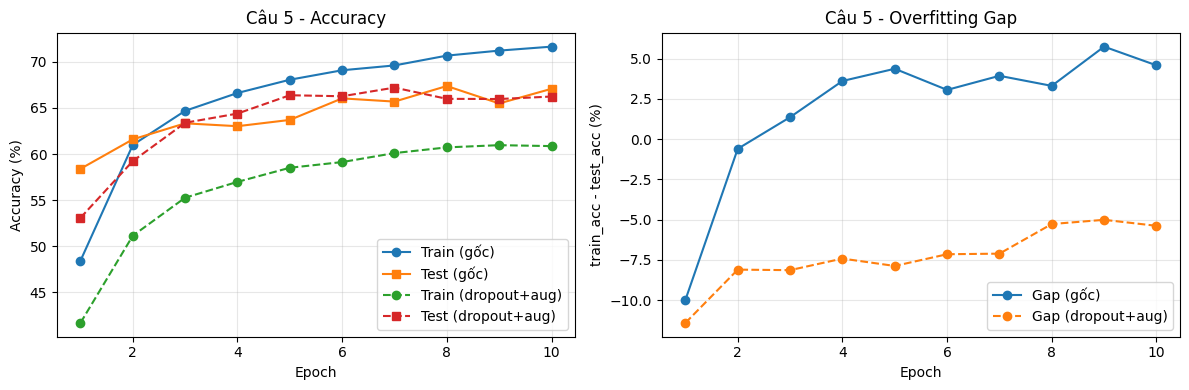


Model gốc    - final test acc: 67.08%  gap: 4.58%
Dropout+Aug  - final test acc: 66.24%  gap: -5.38%


In [ ]:
# ============================================================
# CÂU 5: Thêm Dropout và Data Augmentation
# ============================================================
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_dataset_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform_aug)
train_loader_aug  = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)

class CIFAR_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=0)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1     = nn.Linear(32 * 6 * 6, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

print('--- Model gốc (không dropout, không augmentation) ---')
model5_base = CIFAR_CNN().to(device)
opt5_base = optim.SGD(model5_base.parameters(), lr=0.01, momentum=0.9)
_, acc_base, _, test_acc_base = train(model5_base, opt5_base, 10, train_loader, test_loader)

print('\n--- Model có Dropout + Augmentation ---')
model5_new = CIFAR_CNN_Dropout().to(device)
opt5_new = optim.SGD(model5_new.parameters(), lr=0.01, momentum=0.9)
_, acc_new, _, test_acc_new = train(model5_new, opt5_new, 10, train_loader_aug, test_loader)

epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, [a*100 for a in acc_base],      'o-', label='Train (gốc)')
axes[0].plot(epochs, [a*100 for a in test_acc_base], 's-', label='Test (gốc)')
axes[0].plot(epochs, [a*100 for a in acc_new],       'o--', label='Train (dropout+aug)')
axes[0].plot(epochs, [a*100 for a in test_acc_new],  's--', label='Test (dropout+aug)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Câu 5 - Accuracy')

gap_base = [a - b for a, b in zip(acc_base, test_acc_base)]
gap_new  = [a - b for a, b in zip(acc_new,  test_acc_new)]
axes[1].plot(epochs, [g*100 for g in gap_base], 'o-', label='Gap (gốc)')
axes[1].plot(epochs, [g*100 for g in gap_new],  'o--', label='Gap (dropout+aug)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('train_acc - test_acc (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Câu 5 - Overfitting Gap')
plt.tight_layout(); plt.show()

print(f'\nModel gốc    - final test acc: {test_acc_base[-1]*100:.2f}%  gap: {gap_base[-1]*100:.2f}%')
print(f'Dropout+Aug  - final test acc: {test_acc_new[-1]*100:.2f}%  gap: {gap_new[-1]*100:.2f}%')

`Dropout(p=0.25)` ngẫu nhiên tắt 25% neuron trong mỗi bước train, buộc mạng không phụ thuộc vào một tập neuron cố định → giảm overfitting.
`RandomAffine` + `RandomHorizontalFlip` xoay, dịch chuyển và lật ảnh ngẫu nhiên trong lúc train, tạo ra nhiều biến thể của cùng một vật thể → mô hình tổng quát hóa tốt hơn.
Kết quả: khoảng cách `train_acc - test_acc` (overfitting gap) nhỏ hơn so với mô hình gốc, đặc biệt rõ ở các epoch cuối.
Augmentation chỉ áp dụng cho tập train, KHÔNG áp dụng cho test để đảm bảo đánh giá công bằng.